Importaciones

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
#Me elimina las advertencias
pd.set_option('future.no_silent_downcasting', True)
#Biblioteca basada en Matplotlib, diseñada especialmente para DataFrames
import seaborn as sns

#Tarea 1: Importación de librerías, carga del dataset y eliminación de columnas redundantes.


1.1. Carga el dataset en un dataframe. Usa el fichero de GitHub ubicado este enlace:

In [78]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

# Cargar el dataset en un DataFrame
df = pd.read_csv(url)

1.3. Se eliminarán las columnas Class, Who, Adult_male, Embark_town y Alive

In [79]:
#Elimino las columnas y uso inplace eliminarlas directamente del df original
df.drop(columns=["class","who","adult_male","embark_town","alive"], inplace=True)

#Tarea 2: Normalización/codificación de columnas:

2.1. La columna sex debe normalizarse de forma numérica como entero, siendo 0 para
hombre y 1 para mujer.

In [80]:
df["sex"]=df["sex"].replace(["male","female"],[0,1])

2.2. La columna Embarked debe normalizarse de forma numérica, siendo 0 para
Cherbourg, 1 para Queenstown y 2 para Southampton.

In [81]:
df["embarked"]=df["embarked"].replace(["C","Q","S"],[0,1,2])

2.3. La columna Deck debe normalizarse de forma numérica, siendo 0 para A, 1 para B, …
y 6 para G.

In [82]:
df["deck"]=df["deck"].replace(["A","B","G"],[0,1,2])

2.4. La columna Alone debe normalizarse de forma numérica, siendo 0 si no viajaba solo
y 1 si viajaba solo.

In [83]:
df["alone"]=df["alone"].replace([False,True],[1,0])

#Tarea 3: Limpieza de datos vacíos y de datos fuera de rango

3.1. Obtén el nº de filas vacías para cada atributo (utiliza el método
pandas.DataFrame.info). Localiza para cada tributo aquellos valores que están fuera
del rango indicado. Con los resultados, haz las siguientes eliminaciones:

-Si en alguna de las columnas el porcentaje de datos vacíos o fuera de rango
es superior al 25%, elimina esa columna completa.

-En el resto, elimina las filas completas que tengan algún atributo vacío o
fuera de rango.

In [84]:
#print(df.info())
#Elimino deck que es la que tiene más de 25% de null
df.drop(columns=["deck"], inplace=True)

#Elimina las filas que tienen algún NaN
df.dropna(inplace=True)
print(df.value_counts(df["fare"]<=0))
df = df[df["fare"] > 0]
print(df.info())
print(df.columns)

fare
False    705
True       7
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 705 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  705 non-null    int64  
 1   pclass    705 non-null    int64  
 2   sex       705 non-null    object 
 3   age       705 non-null    float64
 4   sibsp     705 non-null    int64  
 5   parch     705 non-null    int64  
 6   fare      705 non-null    float64
 7   embarked  705 non-null    object 
 8   alone     705 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 55.1+ KB
None
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'alone'],
      dtype='object')


#Tarea 4: Cálculos estadísticos básicos.

4.1. Haz un análisis estadístico relacionando el atributo Sex con el target (Survived).
Muestra datos numéricos y un gráfico similar a este:

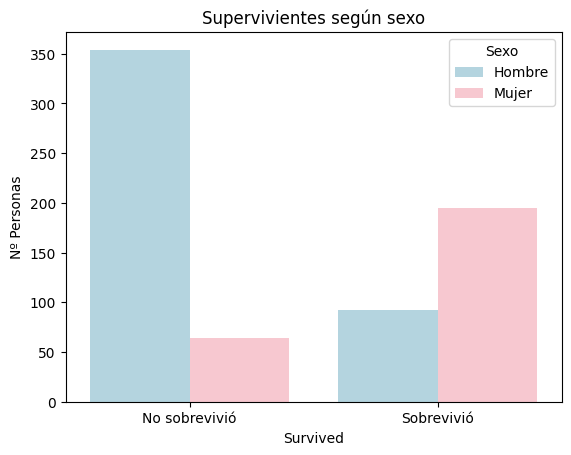

In [85]:
#Método para el conteo de observaciones mediante grafica de barras / hue=division de color según la columna
sns.countplot(data=df, x="survived", hue="sex", palette={0: "lightblue", 1: "pink"})

#Personalizar la gráfica
plt.xlabel("Survived")
plt.ylabel("Nº Personas")
plt.title("Supervivientes según sexo")
plt.xticks([0, 1], ["No sobrevivió", "Sobrevivió"])
plt.legend(title="Sexo", labels=["Hombre", "Mujer"])

# Mostrar la gráfica
plt.show()

4.2. Haz un análisis estadístico relacionando el atributo Pclass con el target (Survived).
Muestra datos numéricos y un gráfico similar al anterior.

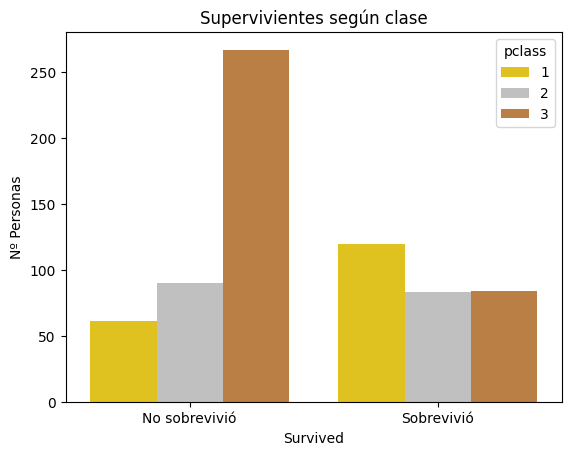

In [86]:
#Color oro, plata y bronce para el tipo de clase
sns.countplot(data=df, x="survived", hue="pclass", palette={1: "#FFD700", 2: "#C0C0C0", 3: "#CD7F32"})

plt.xlabel("Survived")
plt.ylabel("Nº Personas")
plt.xticks([0, 1], ["No sobrevivió", "Sobrevivió"])
plt.title("Supervivientes según clase")

plt.show()

4.3. Haz un análisis estadístico de la edad de los pasajeros que contenga, al menos, la
media, la mediana, la desviación típica, el mínimo, el máximo, y los cuartiles Q1, Q2 y
Q3. Representa la distribución de la edad de forma gráfica

Análisis de Edades
Media=29.587475177304963
Mediana=28.0
Desviación típica=14.524924693994642
Mínimo=0.42
Máximo=80.0
count    705.000000
mean      29.587475
std       14.524925
min        0.420000
25%       20.000000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64


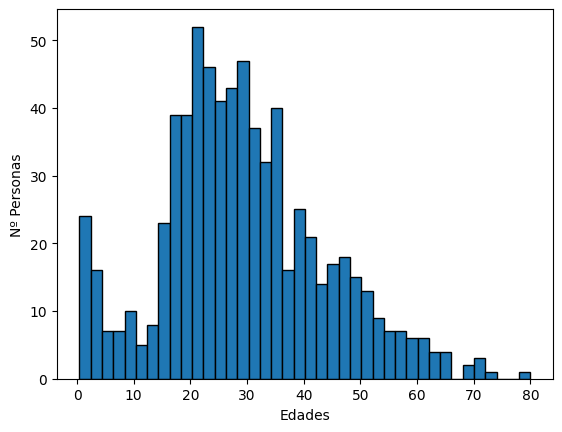

In [87]:
print("Análisis de Edades")

media=df["age"].mean()
print(f"Media={media}")

mediana=df["age"].median()
print(f"Mediana={mediana}")

desviacionT=df["age"].std()
print(f"Desviación típica={desviacionT}")

min=df["age"].min()
print(f"Mínimo={min}")

max=df["age"].max()
print(f"Máximo={max}")

print(df["age"].describe())

#Bins= el número de intervalos en el eje x por lo que en cada intervalo hay menos personas que si pongo bins=20
plt.hist(df["age"], bins=40, edgecolor='black')
plt.xlabel("Edades")
plt.ylabel("Nº Personas")

plt.show()

#Tarea 5: Escalamiento de los datos

5.1. Escala los atributos por el método de estandarización por rangos (MinMaxScaler)

In [88]:
#MinMaxScaler convierte inplícitamente a float el tipo object si todos los valores son cadenas que representan números, por lo que sí funcionaría
numeric_cols = df.select_dtypes(include=['float64', 'int',"object"]).columns.to_list() #Devuelve el nombre de las columnas que cumplan el criterio

#En este caso remainder='passthrough' no haría falta aunque lo deje
preprocessor_MM = ColumnTransformer([('scale', MinMaxScaler(), numeric_cols)],remainder='passthrough')

#Devuelve un array bidimensional con los datos ya escalados en formato que le gusta a los modelos
Data_prep_MM = preprocessor_MM.fit_transform(df)

#Muestra 705,9 que es lo correcto, 705 filas y 9 propiedades por fila
print(Data_prep_MM.shape)

#Lo transformo a un df para ver como quedaría por columnas y filas y para luego descargar
df_procesado = pd.DataFrame(Data_prep_MM, columns=numeric_cols)
#print(df_procesado.to_string())
print(df_procesado)
print(df.columns)


(705, 9)
     survived  pclass  sex       age  sibsp     parch      fare  embarked  \
0         0.0     1.0  0.0  0.271174    0.2  0.000000  0.006369       1.0   
1         1.0     0.0  1.0  0.472229    0.2  0.000000  0.132340       0.0   
2         1.0     1.0  1.0  0.321438    0.0  0.000000  0.007697       1.0   
3         1.0     0.0  1.0  0.434531    0.2  0.000000  0.096569       1.0   
4         0.0     1.0  0.0  0.434531    0.0  0.000000  0.007943       1.0   
..        ...     ...  ...       ...    ...       ...       ...       ...   
700       0.0     1.0  1.0  0.484795    0.0  0.833333  0.049403       0.5   
701       0.0     0.5  0.0  0.334004    0.0  0.000000  0.017681       1.0   
702       1.0     0.0  1.0  0.233476    0.0  0.000000  0.051125       1.0   
703       1.0     0.0  0.0  0.321438    0.0  0.000000  0.051125       0.0   
704       0.0     1.0  0.0  0.396833    0.0  0.000000  0.007353       0.5   

     alone  
0      1.0  
1      1.0  
2      0.0  
3      1.0  
4

#Tarea 6: Guarda el dataframe modificado en un fichero csv

6.1. Guarda el dataframe con todas las modificaciones en tu disco local, con el nombre

titanic_nombre_apellido1_apellido2.csv.

Observa el siguiente ejemplo para exportar un dataframe a csv y descargarlo al disco
local de tu PC:


from google.colab import files

mi_dataframe.to_csv('mi_csv.csv')

files.download('mi_csv.csv')

In [ ]:
from google.colab import files

df_procesado.to_csv('titanic.csv',index=False)

files.download('titanic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>